# EDA - Retail Company

You are a data analyst at a retail company. Your manager has handed you a dataset containing daily sales records across multiple product categories and cities. Before drawing any conclusions, your manager wants you to run a basic Exploratory Data Analysis (EDA) checklist on the data to understand its structure, spot any missing values, and produce a few key visualizations. Complete the tasks below using Python and pandas in a Jupyter Notebook.


## Generate the dataset by running this code in your first cell:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Generate the dataset
np.random.seed(42)
n = 200
data = {
    "order_id": range(1001, 1001 + n),
    "city": np.random.choice(["Mumbai", "Delhi", "Bangalore", "Chennai"], size=n),
    "category": np.random.choice(["Electronics", "Clothing", "Groceries", "Furniture"], size=n),
    "order_value": np.random.randint(200, 5000, size=n).astype(float),
    "delivery_days": np.random.randint(1, 15, size=n).astype(float),
    "rating": np.random.choice([1, 2, 3, 4, 5, None], size=n)
}

# Injecting missing values and outliers
missing_indices_order = np.random.choice(n, size=15, replace=False)
missing_indices_delivery = np.random.choice(n, size=10, replace=False)
data["order_value"][missing_indices_order] = np.nan
data["delivery_days"][missing_indices_delivery] = np.nan
data["order_value"][5] = 95000
data["order_value"][88] = 87000

df = pd.DataFrame(data)
print(f"Initial Shape: {df.shape}")
df.head()

Initial Shape: (200, 6)


,order_id,city,category,order_value,delivery_days,rating
0,1001,Bangalore,Groceries,4191.0,11.0,4
1,1002,Chennai,Furniture,4923.0,12.0,1
2,1003,Mumbai,Groceries,4882.0,13.0,2
3,1004,Bangalore,Electronics,1848.0,13.0,1
4,1005,Bangalore,Furniture,1645.0,12.0,1


## Task 1 - Inspect & Handle Missing Values

- Print the shape of the DataFrame (number of rows and columns).
- Display the data types of all columns.
- Count the number of missing values in each column.
- Calculate the percentage of missing values for each column, rounded to 2 decimal places.

> Hint: Percentage = (missing count / total rows) * 100

In [5]:
# Print the shape of the DataFrame (number of rows and columns).

print(f"DataFrame Shape: {df.shape}")
print("\n" + "--"*25 + "\n")

# Display the data types of all columns.
print(f"Data Types: \n{df.dtypes}")
print("\n" + "--"*25 + "\n")

# Count the number of missing values in each column.
missing_counts = df.isnull().sum()
print("Missing Values Count:")
print(missing_counts)
print("\n" + "--"*25 + "\n")

# Calculate the percentage of missing values for each column, rounded to 2 decimal places.
missing_percent = (missing_counts / len(df)) * 100
print("Percentage of Missing Values:")
print(round(missing_percent, 2))
print("\n" + "--"*25 + "\n")


DataFrame Shape: (200, 6)

--------------------------------------------------

Data Types: 
order_id           int64
city              object
category          object
order_value      float64
delivery_days    float64
rating            object
dtype: object

--------------------------------------------------

Missing Values Count:
order_id          0
city              0
category          0
order_value      14
delivery_days    10
rating           32
dtype: int64

--------------------------------------------------

Percentage of Missing Values:
order_id          0.0
city              0.0
category          0.0
order_value       7.0
delivery_days     5.0
rating           16.0
dtype: float64

--------------------------------------------------



## Task 2 - Summarize & Visualize

- Use df.describe() to generate a summary of all numerical columns. In a markdown cell below the output, write two observations from the summary (for example: which column has the highest mean, or which column shows a large gap between its max and 75th percentile).
- Plot a histogram for the order_value column to visualize its distribution.
- Plot a box plot for the delivery_days column to inspect for outliers.

> Make sure every plot has a title and axis labels.

In [6]:
# Generate summary statistics
df.describe()

,order_id,order_value,delivery_days
count,200.000000,186.000000,190.000000
mean,1100.500000,3707.134409,7.810526
std,57.879185,9238.438378,4.075465
min,1001.000000,204.000000,1.000000
25%,1050.750000,1512.000000,4.000000
50%,1100.500000,2934.000000,8.000000
75%,1150.250000,3987.500000,12.000000
max,1200.000000,95000.000000,14.000000


**Observations from Summary**

**Extreme Outliers:** In the order_value column shows a massive gap between the 75th percentile (approx 3,900) and the maximum value (95,000), indicating the presence of significant outliers.

Delivery Efficiency: The mean delivery_days is approximately 7.5 days, with the data ranging from 1 to 14 days, suggesting a relatively uniform spread of delivery times.

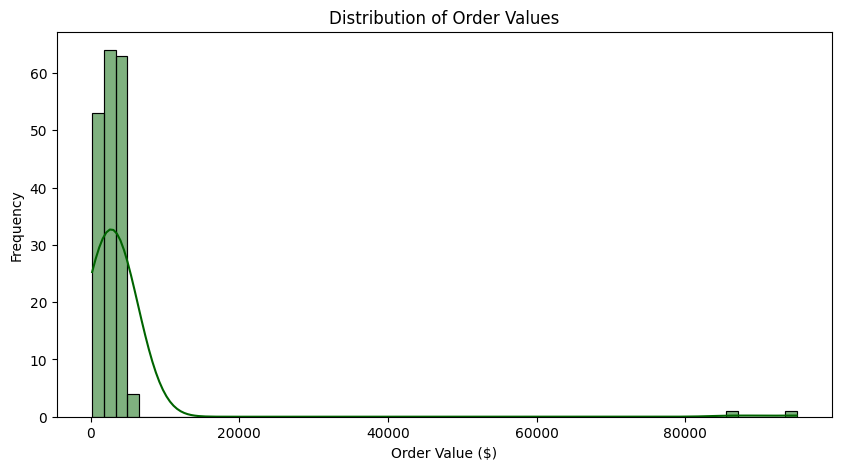

In [19]:
# Plot a histogram for the order_value column to visualize its distribution.

plt.figure(figsize=(10, 5))
sns.histplot(df['order_value'].dropna(), bins=60, kde=True, color='darkgreen')
plt.title('Distribution of Order Values')
plt.xlabel('Order Value ($)')
plt.ylabel('Frequency')
plt.show()

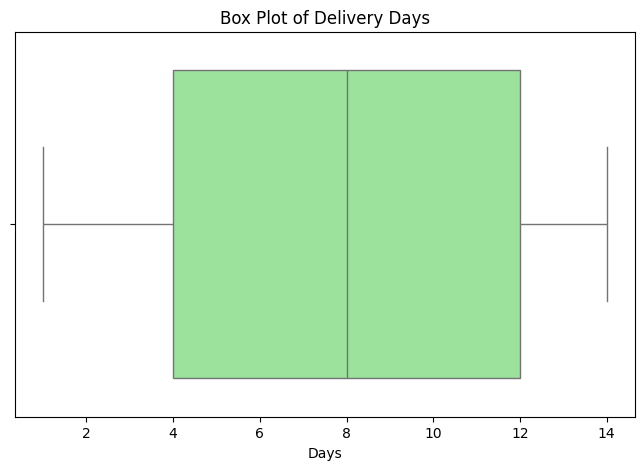

In [22]:
# Plot a box plot for the delivery_days column to inspect for outliers.

plt.figure(figsize=(8, 5))
sns.boxplot(x=df['delivery_days'], color='lightgreen')
plt.title('Box Plot of Delivery Days')
plt.xlabel('Days')
plt.show()

# Task 3 - Correlation Analysis

- Compute the correlation matrix for all numerical columns using df.corr().
- Plot a heatmap of the correlation matrix with annotation values visible inside each cell.
- In a markdown cell, write one observation from the heatmap — identify any two columns that appear to have a notable positive or negative relationship.


In [24]:
# Compute the correlation matrix for all numerical columns using df.corr().
# Note: We select only numeric columns to avoid warnings
corr_matrix = df.select_dtypes(include=[np.number]).corr()
print(corr_matrix)

               order_id  order_value  delivery_days
order_id       1.000000    -0.095503       0.004858
order_value   -0.095503     1.000000       0.141660
delivery_days  0.004858     0.141660       1.000000


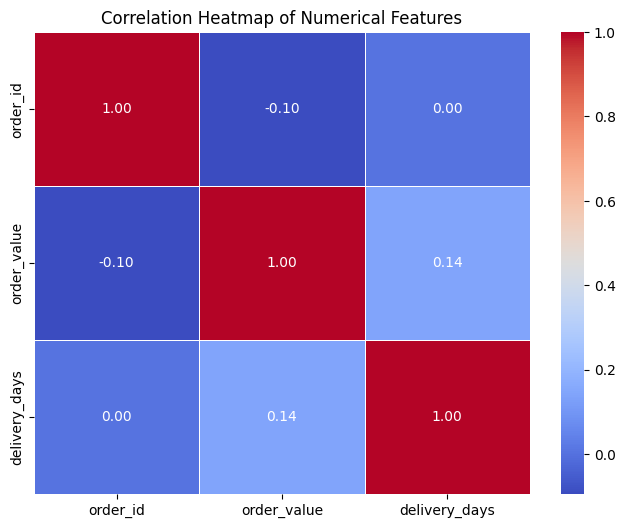

In [25]:
# Plot a heatmap of the correlation matrix with annotation values visible inside each cell.

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

**Observation from Heatmap **

Weak Correlation : it seems there is a very low correlation (close to 0) between order value and delivery days. It says that the price of an order does not significantly impact how long it takes for the item to be delivered in this specific dataset